# [Demo] Aprofundando em Estado (reducers)

Até aqui, cada campo do estado tinha um dono: só um nó escrevia nele. Aqui dois nós disputam
o mesmo campo ao mesmo tempo, e vemos como resolver isso.

O que vamos ver:
- o problema de duas escritas concorrentes no mesmo campo;
- reducers: acumular em vez de sobrescrever;
- `add_messages` como o reducer que já usamos sem perceber;
- estado customizado além das mensagens;
- `trim_messages` para controlar a janela de contexto.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from typing import TypedDict
import operator
from typing import Annotated
from IPython.display import Image, display
from langchain.messages import trim_messages, HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, StateGraph, START, END
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## O problema: duas escritas, um campo só

Recepção e triagem automática rodam em paralelo, direto a partir de `START`, e as duas tentam anotar no
mesmo campo do estado.

In [4]:
class IntakeState(TypedDict):
    notes: str

In [5]:
def reception_note(state: IntakeState) -> dict:
    return {"notes": "Recepção: paciente chegou no horário."}

In [6]:
def triage_note(state: IntakeState) -> dict:
    return {"notes": "Triagem automática: sem sintomas de urgência."}

## Dois nós, direto de START

Sem aresta entre os dois nós, ambos disparam em paralelo assim que o grafo começa.

In [7]:
builder = StateGraph(IntakeState)
builder.add_node("reception_note", reception_note)
builder.add_node("triage_note", triage_note)

In [8]:
builder.add_edge(START, "reception_note")
builder.add_edge(START, "triage_note")
builder.add_edge("reception_note", END)
builder.add_edge("triage_note", END)

In [9]:
graph = builder.compile()

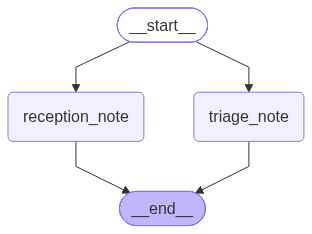

In [10]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Rodando: quem vence?

O LangGraph não escolhe por você. Duas escritas no mesmo campo, na mesma etapa, param a execução.

In [11]:
try:
    graph.invoke({"notes": ""})
except Exception as error:
    print(error)

At key 'notes': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


## Reducers: acumular em vez de sobrescrever

Um reducer diz ao LangGraph como combinar escritas concorrentes no mesmo campo. `operator.add` numa lista
transforma "quem escreve por último" em "todo mundo escreve, e as escritas se somam".

In [12]:
class IntakeStateWithReducer(TypedDict):
    notes: Annotated[list[str], operator.add]

In [13]:
def reception_note(state: IntakeStateWithReducer) -> dict:
    return {"notes": ["Recepção: paciente chegou no horário."]}

In [14]:
def triage_note(state: IntakeStateWithReducer) -> dict:
    return {"notes": ["Triagem automática: sem sintomas de urgência."]}

In [15]:
builder = StateGraph(IntakeStateWithReducer)
builder.add_node("reception_note", reception_note)
builder.add_node("triage_note", triage_note)
builder.add_edge(START, "reception_note")
builder.add_edge(START, "triage_note")
builder.add_edge("reception_note", END)
builder.add_edge("triage_note", END)

In [16]:
graph = builder.compile()

In [17]:
graph.invoke({"notes": []})

{'notes': ['Recepção: paciente chegou no horário.',
  'Triagem automática: sem sintomas de urgência.']}

## add_messages já é um reducer

O `MessagesState` que já usamos não tem tratamento especial: `messages` é só
`Annotated[list, add_messages]`. É o mesmo mecanismo de `operator.add`, só que com uma regra própria para
mensagens (anexa novas, atualiza uma existente se o `id` já apareceu na lista).

## Estado customizado além das mensagens

`MessagesState` não precisa ser o estado inteiro: dá para estender com campos próprios. Aqui, um campo
`specialty` guarda a especialidade detectada na mensagem do paciente, ao lado do histórico de conversa.

In [18]:
class TriageState(MessagesState):
    specialty: str

In [19]:
def detect_specialty(state: TriageState) -> dict:
    message = state["messages"][-1].content.lower()
    if "cora" in message:
        specialty = "cardiologia"
    elif "pele" in message or "derma" in message:
        specialty = "dermatologia"
    else:
        specialty = "clínica geral"
    return {"specialty": specialty}

In [20]:
builder = StateGraph(TriageState)
builder.add_node("detect_specialty", detect_specialty)
builder.add_edge(START, "detect_specialty")
builder.add_edge("detect_specialty", END)

In [21]:
graph = builder.compile()

In [23]:
graph.invoke({"messages": [HumanMessage("Estou com uma dor forte no coração")]})

{'messages': [HumanMessage(content='Estou com uma dor forte no coração', additional_kwargs={}, response_metadata={}, id='82a43fa5-7a02-4f3b-8c16-491718f9934e')],
 'specialty': 'cardiologia'}

## Limite de tokens: trim_messages

`add_messages` acumula para sempre. Numa conversa longa, isso estoura a janela de contexto do modelo.
`trim_messages` corta o histórico, mantendo o `SystemMessage` e as mensagens mais recentes.

In [24]:
history = [
    SystemMessage("Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva."),
    HumanMessage("Qual o horário de funcionamento?"),
    AIMessage("Atendemos de segunda a sexta, das 08h às 18h."),
    HumanMessage("E aos sábados?"),
    AIMessage("Aos sábados, das 08h às 12h."),
    HumanMessage("Consigo marcar uma consulta pelo WhatsApp?"),
]

In [40]:
trimmed = trim_messages(
    history,
    strategy="last",
    token_counter=model,
    max_tokens=80,
    include_system=False,
    allow_partial=False,
    start_on="human"
)

In [41]:
for message in trimmed:
    print(type(message).__name__, ":", message.content)

HumanMessage : Qual o horário de funcionamento?
AIMessage : Atendemos de segunda a sexta, das 08h às 18h.
HumanMessage : E aos sábados?
AIMessage : Aos sábados, das 08h às 12h.
HumanMessage : Consigo marcar uma consulta pelo WhatsApp?


## Takeaway

Um reducer resolve quem escreve o quê quando duas etapas tocam o mesmo campo, `add_messages` é só um
reducer especializado em conversas, e `trim_messages` mantém essa conversa dentro da janela de contexto.